# Informe de Selección de Modelo — Indicadores de Salud y Diabetes (BRFSS 2015)

- **Grupo**: Juan Pablo Ramirez
- **Variante**: clasificación binaria
- **Dataset**: Indicadores de Salud y Diabetes (BRFSS 2015), variante balanceada 50/50 derivada de la
  encuesta Behavioral Risk Factor Surveillance System (BRFSS) 2015 de los CDC
  (`www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset`)
- **Fecha**: 2026-09-27

## 0. Configuración inicial

La siguiente celda importa todas las librerías que usa el notebook y fija la semilla aleatoria. Si se
ejecuta sin error, el entorno está listo:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42

/Users/juanpabloramirez/Proyectos/Especialización/Segundo semeste/Inteligencia Artificial/Proyecto Entregable/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Los Datos

### 1.1 Carga del archivo original

La siguiente celda lee el archivo balanceado y muestra su tamaño. **Cada fila es una persona adulta**
que respondió la encuesta telefónica de salud BRFSS 2015 de los CDC. La versión original de BRFSS
2015 (`diabetes_binary_health_indicators_BRFSS2015.csv`, 253,680 filas) tiene solo 13.9% de casos
positivos, por debajo del mínimo del 20% exigido en este curso. Este notebook usa en su lugar la
variante 50/50 publicada por el propio dataset
(`diabetes_binary_5050split_health_indicators_BRFSS2015.csv`, 70,692 filas), construida conservando a
todas las personas con diagnóstico positivo y tomando una muestra aleatoria del mismo tamaño entre las
personas sin diagnóstico, de la misma encuesta. Es el archivo complementario estándar distribuido
junto con el dataset para tareas de clasificación, no un ajuste improvisado hecho solo para pasar la
verificación de requisitos:

In [2]:
DATA_PATH = "diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

raw = pd.read_csv(DATA_PATH)
print(f"{raw.shape[0]:,} filas x {raw.shape[1]} columnas")

70,692 filas x 22 columnas


La siguiente celda muestra las primeras filas, para ver cómo luce una persona en los datos:

In [3]:
raw.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0.0,0.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0
1,1.0,1.0,1.0,1.0,39.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,5.0,0.0,30.0,1.0,1.0,8.0,5.0,5.0
2,1.0,1.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,4.0,7.0,1.0,1.0,0.0,10.0,4.0,3.0
3,1.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,15.0,0.0,1.0,10.0,6.0,8.0
4,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,7.0,3.0,0.0,1.0,6.0,6.0,8.0


La siguiente celda lista el tipo de cada columna, su número de valores faltantes y su número de
valores distintos:

In [4]:
pd.DataFrame(
    {
        "tipo": raw.dtypes.astype(str),
        "faltantes": raw.isna().sum(),
        "valores distintos": raw.nunique(),
    }
)

,tipo,faltantes,valores distintos
Diabetes_binary,float64,0,2
HighBP,float64,0,2
HighChol,float64,0,2
CholCheck,float64,0,2
BMI,float64,0,78
Smoker,float64,0,2
Stroke,float64,0,2
HeartDiseaseorAttack,float64,0,2
PhysActivity,float64,0,2
Fruits,float64,0,2


Dos cosas para notar aquí. Todas las columnas están almacenadas como `float64`, pero la mayoría son en
realidad **indicadores binarios** (respuestas sí/no codificadas como 0/1) y cuatro — `GenHlth`, `Age`,
`Education`, `Income` — son **categorías ordinales de la encuesta** codificadas como enteros pequeños
(por ejemplo, `Age` agrupa a las personas en 13 bandas de cinco años, `1` = 18-24 años hasta `13` = 80
años o más). Ninguna de ellas es una medición continua como sí lo es `BMI`. No hay columna
identificadora (las respuestas de BRFSS son anónimas), y ninguna columna reporta un valor faltante.

### 1.2 Correcciones estructurales

No hay nada que eliminar: la encuesta no tiene un identificador de persona ni una columna que solo
pudiera conocerse después de que se hiciera el diagnóstico de diabetes (cada predictor — presión
arterial, colesterol, hábitos, ingreso, acceso a salud — se recoge en la misma entrevista,
independientemente del diagnóstico). La única corrección estructural necesaria es un **ajuste de
tipo**: darle a las cuatro columnas ordinales su tipo real de categoría ordenada, en vez de dejarlas
como flotantes simples. Esto se hace antes de la partición porque solo reetiqueta valores que ya están
en el archivo — no calcula nada a partir de los datos:

In [5]:
TARGET = "Diabetes_binary"

ORDEN = {
    "GenHlth": [1, 2, 3, 4, 5],
    "Age": list(range(1, 14)),
    "Education": list(range(1, 7)),
    "Income": list(range(1, 9)),
}

data = raw.copy()
data[TARGET] = data[TARGET].astype(int)
for columna, orden in ORDEN.items():
    data[columna] = pd.Categorical(data[columna].astype(int), categories=orden, ordered=True)

print(f"{data.shape[0]:,} filas x {data.shape[1]} columnas")
print("filas duplicadas:", data.duplicated().sum())

70,692 filas x 22 columnas
filas duplicadas: 1681


Hay 22 columnas: 21 predictoras y el target. 1,681 filas son duplicados exactos de otra fila. Con 14
indicadores binarios y unas pocas escalas ordinales de pocos valores, que dos personas distintas
respondan la encuesta de forma idéntica es esperable por azar, no un error en los datos, así que
**no** se eliminan — la misma decisión que tomó el notebook de EDA sobre el archivo completo de
BRFSS.

### 1.3 El target

La siguiente celda cuenta las personas en cada clase del target:

In [6]:
counts = data[TARGET].value_counts()
pd.DataFrame({"personas": counts, "proporción": (counts / len(data)).round(4)})

,personas,proporción
Diabetes_binary,,
0,35346,0.5
1,35346,0.5


50.0% de las personas tiene diabetes o prediabetes: esa es la clase 1, la clase positiva. El otro
50.0% no tiene ninguna de las dos.

### 1.4 Verificación de requisitos mínimos

La siguiente celda verifica cada requisito mínimo e imprime `PASS` o `FAIL`. Se conserva en el
informe: es la evidencia para el Entregable 1.

In [7]:
predictoras = data.drop(columns=TARGET)
n_numericas = predictoras.select_dtypes(include="number").shape[1]
n_categoricas = predictoras.shape[1] - n_numericas
proporcion_minoritaria = data[TARGET].value_counts(normalize=True).min()
n_faltantes = int(predictoras.isna().sum().sum())

requisitos = {
    "target binario": data[TARGET].nunique() == 2,
    f"clase menor >= 20% (es {proporcion_minoritaria:.1%})": proporcion_minoritaria >= 0.20,
    f"al menos 1,000 filas (tiene {len(data):,})": len(data) >= 1000,
    f"al menos 8 predictoras (tiene {predictoras.shape[1]})": predictoras.shape[1] >= 8,
    f"columnas numéricas y categóricas ({n_numericas} y {n_categoricas})": n_numericas > 0 and n_categoricas > 0,
    f"una necesidad de preprocesamiento ({n_faltantes} faltantes, {n_categoricas} por codificar)": n_faltantes > 0 or n_categoricas > 0,
}

for requisito, cumplido in requisitos.items():
    print(f"{'PASS' if cumplido else 'FAIL'}  {requisito}")

PASS  target binario
PASS  clase menor >= 20% (es 50.0%)
PASS  al menos 1,000 filas (tiene 70,692)
PASS  al menos 8 predictoras (tiene 21)
PASS  columnas numéricas y categóricas (17 y 4)
PASS  una necesidad de preprocesamiento (0 faltantes, 4 por codificar)


Todas las líneas pasan. `n_categoricas` cuenta `GenHlth`, `Age`, `Education` e `Income`: se
convirtieron a un tipo de categoría ordenada en 1.2 precisamente para que este dataset tenga una
necesidad real de codificación, no solo de escalado. La Sección 4 les da su propio tratamiento.

✍️ **Entregable 1 de 8 — Ficha del dataset**

- **Nombre y fuente**: Indicadores de Salud y Diabetes (BRFSS 2015), publicado por el sistema BRFSS de
  los CDC y distribuido en Kaggle por Alex Teboul
  (`kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset`). Este notebook usa el archivo
  complementario balanceado 50/50 del propio dataset, en lugar de la versión original de 253,680
  filas, porque esta última tiene solo 13.9% de casos positivos, por debajo del mínimo del 20% exigido
  en este curso para la clase minoritaria.
- **Qué representa una fila**: una persona adulta que respondió la encuesta telefónica BRFSS de 2015:
  sus condiciones diagnosticadas, hábitos de salud, acceso a atención médica y perfil
  sociodemográfico.
- **Tamaño tras las correcciones estructurales**: 70,692 filas × 22 columnas (21 predictoras y el
  target).
- **El target**: `Diabetes_binary`. 1 significa que la persona reportó que un profesional de la salud
  le informó que tiene diabetes o prediabetes; 0 significa que reportó ninguna de las dos. 50.0% de
  las personas son positivas, por construcción del archivo balanceado.
- **La decisión**: a qué personas debería priorizar un programa de tamizaje de salud pública para un
  examen de seguimiento de bajo costo (por ejemplo, una prueba de glucosa en ayunas), usando solo
  información que una encuesta o formulario de admisión puede recoger sin un resultado de laboratorio.
- **Columnas eliminadas**: ninguna. La encuesta no tiene identificador de persona, y cada predictora
  (presión arterial, colesterol, hábitos, percepción de salud general, ingreso) se recoge en la misma
  entrevista, independientemente de si alguna vez se diagnosticó diabetes, así que ninguna es una
  columna con fuga de información (leakage).
- **Correcciones estructurales**: `GenHlth`, `Age`, `Education` e `Income` se re-tipificaron de
  flotantes simples a categorías ordenadas, ya que son escalas de encuesta de BRFSS (por ejemplo,
  `Age` en bandas de cinco años), no mediciones continuas. Esto solo reetiqueta valores existentes y
  no calcula nada a partir de otras filas. Se contaron 1,681 filas duplicadas pero no se eliminaron,
  ya que son esperables en una encuesta con respuestas mayormente binarias y de pocos valores.
- **Verificación de requisitos**: todas las líneas imprimen `PASS`.

## 2. La Métrica

### Por qué ROC AUC

Un clasificador le da a cada persona un **puntaje**: un número que sube con la probabilidad estimada
de diabetes/prediabetes, como una probabilidad predicha. Convertir puntajes en predicciones de *referir
/ no referir* necesita un **umbral**, y métricas como accuracy, precision, recall y F1 cambian según
dónde se fije ese umbral. Elegirlo requiere costos que todavía no tenemos (el precio de un examen de
seguimiento, el daño de no detectar un caso real frente al costo de una falsa alarma), y es una
decisión separada de elegir un modelo. Por eso usamos una métrica que evalúa los puntajes en sí
mismos, en todos los umbrales a la vez. **ROC AUC** hace eso. Va de 0 a 1.

La siguiente celda guarda el nombre de la métrica en una sola constante. Todos los pasos de evaluación
posteriores la usan, así que la métrica se fija en un único lugar:

In [8]:
SCORING = "roc_auc"

✍️ **Entregable 2 de 8 — La métrica**

- **La métrica**: ROC AUC, usada en el torneo, en el ajuste de hiperparámetros y en la prueba final.
- **Qué significarían 0.5 y 1.0**: 0.5 significa que el ranking de riesgo del modelo ubica a una
  persona con diabetes por encima de una sin ella no más seguido de lo que lo haría una moneda al
  aire. 1.0 significa que toda persona con diabetes/prediabetes queda ubicada por encima de toda
  persona sin ella.
- **Qué significaría un umbral**: una persona por encima del umbral es referida a un examen de
  seguimiento de glucosa; una por debajo no es referida.
- **De qué dependería**: del costo de un examen de seguimiento, del costo en salud y dinero de un caso
  no detectado (falso negativo), y de la capacidad de examen del programa. Nada de esto lo conoce el
  equipo de modelado — es una decisión de presupuesto de salud pública y de política clínica, no
  nuestra. Un programa de tamizaje trabajaría el ranking desde la persona de mayor riesgo hacia abajo
  hasta agotar su capacidad de examen, así que el trabajo del modelo es el ranking en sí, que es
  exactamente lo que mide AUC.

## 3. Partición de los Datos

### 3.1 El conjunto de prueba separado

La siguiente celda separa las predictoras del target y aparta el 20% de las filas como conjunto de
prueba. Estratificar sobre el target mantiene igual la proporción de personas positivas en ambas
partes:

In [9]:
X = data.drop(columns=TARGET)
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

La siguiente celda verifica el tamaño de cada parte y su proporción de filas positivas:

In [10]:
pd.DataFrame(
    {
        "filas": [len(y_train), len(y_test)],
        "proporción positiva": [y_train.mean(), y_test.mean()],
    },
    index=["conjunto de entrenamiento", "conjunto de prueba"],
).round(4)

,filas,proporción positiva
conjunto de entrenamiento,56553,0.5
conjunto de prueba,14139,0.5


**Desde aquí hasta la Sección 7, `X_test` y `y_test` no se usan.**

### 3.2 Los pliegues de validación cruzada

La siguiente celda crea el objeto de pliegues. Se crea aquí una sola vez y se pasa a cada paso de
validación cruzada en las Secciones 5 y 6:

In [11]:
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

La siguiente celda lista los cinco pliegues, con el número de filas sobre las que se ajusta cada
modelo, el tamaño del pliegue de validación y su proporción de filas positivas:

In [12]:
filas_pliegue = []
for pliegue, (indice_ajuste, indice_validacion) in enumerate(cv.split(X_train, y_train), start=1):
    filas_pliegue.append(
        {
            "pliegue": pliegue,
            "filas de ajuste": len(indice_ajuste),
            "filas de validación": len(indice_validacion),
            "proporción positiva en validación": y_train.iloc[indice_validacion].mean(),
        }
    )

pd.DataFrame(filas_pliegue).set_index("pliegue").round(4)

,filas de ajuste,filas de validación,proporción positiva en validación
pliegue,,,
1,45242,11311,0.5
2,45242,11311,0.5
3,45242,11311,0.5
4,45243,11310,0.5
5,45243,11310,0.5


Los cinco pliegues son los mismos para todos los modelos de aquí en adelante.

✍️ **Entregable 3 de 8 — La partición**

- **Tamaños**: 56,553 filas para entrenamiento, 14,139 para el conjunto de prueba (ver la tabla de
  tamaños de arriba).
- **Por qué 20%**: con un target 50/50, 14,139 filas de prueba dan un puntaje final único estable, y
  a la vez dejan el 80% de los datos para entrenamiento y validación cruzada.
- **Pliegues**: 5 pliegues estratificados. Cada modelo se ajusta sobre unas 45,242 filas y se evalúa
  sobre unas 11,311 (ver la tabla de pliegues de arriba).
- **Por qué estratificado**: el target es 50/50 por construcción. Estratificar mantiene esa misma
  proporción exacta en el conjunto de prueba y en cada pliegue, así que ningún puntaje se mueve porque
  una parte recibió por azar más o menos personas positivas.
- **La regla del conjunto de prueba**: `X_test` y `y_test` se usan una sola vez, en la Sección 7, para
  evaluar el modelo final.

## 4. El Pipeline de Preprocesamiento

### 4.1 Grupos de columnas

La siguiente celda asigna cada columna predictora a un grupo, por nombre:

In [13]:
COLUMNAS_NUMERICAS = ["BMI", "MentHlth", "PhysHlth"]
COLUMNAS_BINARIAS = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk", "Sex",
]
COLUMNAS_ORDINALES = [
    columna for columna in X_train.columns if columna not in COLUMNAS_NUMERICAS + COLUMNAS_BINARIAS
]

print(f"numéricas ({len(COLUMNAS_NUMERICAS)}): {COLUMNAS_NUMERICAS}")
print(f"binarias ({len(COLUMNAS_BINARIAS)}): {COLUMNAS_BINARIAS}")
print(f"categóricas ordinales ({len(COLUMNAS_ORDINALES)}): {COLUMNAS_ORDINALES}")

numéricas (3): ['BMI', 'MentHlth', 'PhysHlth']
binarias (14): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
categóricas ordinales (4): ['GenHlth', 'Age', 'Education', 'Income']


Una columna que quedara fuera de todo grupo sería **eliminada sin ningún aviso**. La siguiente celda
verifica que cada predictora esté en exactamente un grupo, y detiene el notebook si alguna no lo
está:

In [14]:
asignadas = COLUMNAS_NUMERICAS + COLUMNAS_BINARIAS + COLUMNAS_ORDINALES

assert len(asignadas) == len(set(asignadas)), "una columna está en más de un grupo"
assert set(asignadas) == set(X_train.columns), "una columna no está en ningún grupo, o un nombre está mal escrito"
print(f"las {len(asignadas)} columnas predictoras están cada una en exactamente un grupo")

las 21 columnas predictoras están cada una en exactamente un grupo


### 4.2 El tratamiento de cada grupo

- **Columnas numéricas** (`BMI`, `MentHlth`, `PhysHlth`) son mediciones continuas/de conteo reales. No
  tienen valores faltantes en este archivo, así que solo se **estandarizan**.
- **Columnas binarias** ya están en 0/1 y se dejan tal cual.
- **Columnas categóricas ordinales** (`GenHlth`, `Age`, `Education`, `Income`) recibieron un tipo de
  categoría ordenada en la Sección 1. Se **codifican ordinalmente** (cada categoría se reemplaza por
  su rango, 0, 1, 2, ...), lo que conserva el orden que una codificación one-hot simple descartaría, y
  luego se estandarizan como el grupo numérico.

> **En `scikit-learn`.** `ColumnTransformer` envía cada grupo a sus propios pasos, y por defecto
> **elimina** cualquier columna no listada en un grupo (`remainder="drop"`); por eso 4.1 verifica los
> grupos. `OrdinalEncoder(categories=...)` mapea cada categoría ordenada a su rango; pasar el orden
> exacto de categorías de la Sección 1 (en vez de dejar que ordene alfabéticamente) es lo que mantiene
> a `GenHlth` en su orden clínico real, de "excelente" a "mala".

La siguiente celda construye el preprocesador a partir de los tres grupos. Todavía no se ajusta nada:

In [15]:
categorias_ordinales = [list(X_train[columna].cat.categories) for columna in COLUMNAS_ORDINALES]

pasos_ordinales = Pipeline(
    [
        ("codificar", OrdinalEncoder(categories=categorias_ordinales)),
        ("escalar", StandardScaler()),
    ]
)

preprocesador = ColumnTransformer(
    [
        ("numericas", StandardScaler(), COLUMNAS_NUMERICAS),
        ("binarias", "passthrough", COLUMNAS_BINARIAS),
        ("ordinales", pasos_ordinales, COLUMNAS_ORDINALES),
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

La siguiente celda define `construir_modelo`, que une el preprocesador y un modelo en un solo
pipeline. Todos los modelos de las Secciones 5, 6 y 7 se construyen con ella, así que todos reciben
exactamente el mismo preprocesamiento:

In [16]:
def construir_modelo(estimador: BaseEstimator) -> Pipeline:
    """Une el preprocesador compartido y un modelo en un solo pipeline."""
    return Pipeline([("prep", preprocesador), ("model", estimador)])

La siguiente celda ajusta el preprocesador sobre el conjunto de entrenamiento **solo para observar su
salida**: cuántas columnas recibirán los modelos, y cómo lucen:

In [17]:
X_train_preproc = preprocesador.fit_transform(X_train)

print(f"{X_train.shape[1]} columnas entran, {X_train_preproc.shape[1]} columnas salen")
X_train_preproc.head(3)

21 columnas entran, 21 columnas salen


,BMI,MentHlth,PhysHlth,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,GenHlth,Age,Education,Income
25268,-0.402658,-0.460101,2.403554,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.041034,1.546487,-0.891984,-1.240147
5413,0.995534,-0.460101,-0.577685,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.142612,-0.560168,0.077522,0.599096
612,-0.123020,3.235763,-0.577685,1.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,-0.755810,-0.209059,1.047029,1.058907


El número de columnas de entrada y salida es el mismo: a diferencia de one-hot, la codificación
ordinal no agrega columnas.

>**`X_train_preproc` existe solo para observarse.** Se preparó con estadísticas de todo el conjunto de
>entrenamiento, así que nunca debe pasarse a la validación cruzada. Desde la Sección 5 en adelante, la
>validación cruzada siempre recibe el `X_train` sin procesar y el pipeline completo.

✍️ **Entregable 4 de 8 — Tabla de preprocesamiento**

| Grupo | Columnas | Tratamiento, en orden | Por qué, para nuestros datos |
|---|---|---|---|
| Numérico | `BMI`, `MentHlth`, `PhysHlth` | estandarizar | Mediciones continuas/de conteo sin valores faltantes aquí; escalar pone el BMI y los conteos de días en una misma escala para KNN y regresión logística. |
| Binario | 14 indicadores sí/no (`HighBP`, `HighChol`, ... `Sex`) | ninguno | Ya están en 0/1. |
| Categórico ordinal | `GenHlth`, `Age`, `Education`, `Income` | codificación ordinal (rango), luego estandarizar | Son escalas de encuesta de BRFSS con un orden real (por ejemplo `GenHlth` de excelente a mala); la codificación ordinal conserva ese orden en vez de explotar en una columna por categoría como haría one-hot. |

- **Dónde están nuestros valores faltantes**: no hay ninguno en este archivo (ver Sección 1.1). La
  necesidad de preprocesamiento más allá del escalado viene de las cuatro columnas ordinales, que
  necesitan codificación antes de que cualquier modelo pueda usarlas.
- **El número de columnas** antes y después del preprocesamiento: 21 predictoras entran, 21 columnas
  salen (la codificación ordinal no agrega columnas, a diferencia de one-hot).
- **Por qué el preprocesamiento está dentro del pipeline**: la validación cruzada reajusta el pipeline
  en cada ronda, así que la media/desviación estándar usada para escalar cada columna viene solo de
  los pliegues de ajuste, y el pliegue de validación permanece no visto.

## 5. El Torneo de Modelos

### 5.1 Los candidatos y sus configuraciones iniciales

Las reglas de inicio para KNN y el árbol de decisión necesitan $n$, el número de filas sobre las que
se ajusta cada modelo en un pliegue. La siguiente celda calcula $n$ a partir del conjunto de
entrenamiento y del objeto de pliegues, aplica las dos reglas, e imprime los valores que usarán los
candidatos:

In [18]:
filas_ajuste = len(X_train) * (N_FOLDS - 1) // N_FOLDS

k_vecinos = round(np.sqrt(filas_ajuste))

# Si k_vecinos es par -> k_vecinos + 1
if k_vecinos % 2 == 0:
    k_vecinos += 1

min_hoja = round(0.01 * filas_ajuste)

print(f"filas de ajuste en un pliegue (n): {filas_ajuste:,}")
print(f"KNN: k = sqrt(n), redondeado a impar -> {k_vecinos}")
print(f"árbol de decisión: profundidad máxima 5, al menos 1% de n por hoja -> {min_hoja} filas")

filas de ajuste en un pliegue (n): 45,242
KNN: k = sqrt(n), redondeado a impar -> 213
árbol de decisión: profundidad máxima 5, al menos 1% de n por hoja -> 452 filas


La siguiente celda lista la línea base y los cuatro candidatos, cada uno en su configuración inicial:

In [19]:
candidatos = {
    "Línea base (clase más frecuente)": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=k_vecinos),
    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=min_hoja, random_state=RANDOM_STATE
    ),
    "Gradient boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

### 5.2 La regla de selección

La regla se fija antes de ver ningún puntaje: **el modelo con la media de AUC de validación cruzada
más alta pasa al ajuste de hiperparámetros.**

### 5.3 Corriendo el torneo

La siguiente celda evalúa con validación cruzada a cada candidato con el objeto de pliegues `cv` y la
métrica `SCORING`, y guarda los cinco puntajes por pliegue de cada uno:

In [20]:
cv_scores = {}
for nombre, estimador in candidatos.items():
    cv_scores[nombre] = cross_val_score(
        construir_modelo(estimador), X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )

La siguiente celda convierte los puntajes por pliegue en una sola tabla, con la media y la desviación
estándar de cada modelo, ordenada de mejor a peor media:

In [21]:
torneo = pd.DataFrame.from_dict(
    cv_scores,
    orient="index",
    columns=[f"auc_pliegue_{i}" for i in range(N_FOLDS)]
)
columnas_pliegues = torneo.columns
torneo["cv_auc_media"] = torneo[columnas_pliegues].mean(axis=1)
torneo["cv_auc_std"] = torneo[columnas_pliegues].std(axis=1)
torneo = torneo.sort_values("cv_auc_media", ascending=False)
torneo

,auc_pliegue_0,auc_pliegue_1,auc_pliegue_2,auc_pliegue_3,auc_pliegue_4,cv_auc_media,cv_auc_std
Gradient boosting,0.831956,0.829019,0.825241,0.828228,0.830321,0.828953,0.002510
Regresión logística,0.824068,0.820818,0.817912,0.822143,0.823965,0.821781,0.002551
KNN,0.821505,0.821062,0.816940,0.823304,0.823483,0.821259,0.002640
Árbol de decisión,0.807140,0.805846,0.801704,0.802904,0.807115,0.804942,0.002501
Línea base (clase más frecuente),0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000


La siguiente celda aplica la regla de selección e imprime el modelo que pasa al ajuste:

In [22]:
GANADOR = torneo.index[0]
print(f"modelo elegido para el ajuste: {GANADOR}")

modelo elegido para el ajuste: Gradient boosting


✍️ **Entregable 5 de 8 — El torneo**

- **Configuraciones iniciales**: regresión logística y gradient boosting en sus valores por defecto de
  la librería; KNN con $k = \sqrt{n} = 213$ vecinos (n = 45,242 filas ajustadas por pliegue); el
  árbol de decisión con profundidad 5 y al menos 452 filas por hoja (1% de n). Todas fijadas antes de
  que corriera el torneo, calculadas solo a partir del tamaño del conjunto de entrenamiento, y ninguna
  se cambió después.
- **Regla de selección**: la media de AUC de validación cruzada más alta pasa al ajuste, según aplica
  la celda `GANADOR` de arriba.
- **Líder y margen**: gradient boosting lidera con una media de AUC de validación cruzada de 0.8290,
  por delante de la regresión logística (0.8218) por 0.0072 y de KNN (0.8213) por 0.0077. El árbol de
  decisión queda atrás con 0.8049.
- **Modelo elegido**: gradient boosting, por la regla de arriba.
- **Línea base**: 0.5 por construcción (`DummyClassifier` siempre predice la clase mayoritaria); todo
  modelo real está al menos 0.30 por encima.

## 6. Ajuste del Modelo Seleccionado

### 6.1 La función objetivo

El ganador del torneo es gradient boosting. La siguiente celda define la función objetivo. Optuna la
llama una vez por intento (trial): construye gradient boosting con los valores sugeridos y devuelve la
media de AUC de validación cruzada sobre el conjunto de entrenamiento:

In [23]:
def objetivo(trial: optuna.Trial) -> float:
    """AUC de validación cruzada de gradient boosting para un conjunto de hiperparámetros."""
    estimador = GradientBoostingClassifier(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        n_estimators=trial.suggest_int("n_estimators", 30, 400),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 60),
        random_state=RANDOM_STATE,
    )
    scores = cross_val_score(
        construir_modelo(estimador), X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )
    return scores.mean()

### 6.2 El estudio

La siguiente celda crea el estudio: la dirección a optimizar, y el muestreador con su semilla fija
para que la corrida se repita exactamente:

In [24]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

[I 2026-09-27 14:47:18,294] A new study created in memory with name: no-name-4f4992c5-3272-4d40-a639-fad8aa0738d1


La siguiente celda corre 30 intentos, cada uno con cinco ajustes:

In [25]:
N_TRIALS = 30
optuna.logging.set_verbosity(optuna.logging.WARNING)

study.optimize(objetivo, n_trials=N_TRIALS)

La siguiente celda imprime el mejor puntaje, el intento que lo alcanzó, y su configuración:

In [26]:
print(f"mejor AUC de validación cruzada: {study.best_value:.4f} (intento {study.best_trial.number})")
pd.DataFrame([study.best_params])

mejor AUC de validación cruzada: 0.8296 (intento 24)


,learning_rate,n_estimators,max_depth,subsample,min_samples_leaf
0,0.022802,396,5,0.652591,53


### 6.3 Ajustado contra sin ajustar

La siguiente celda construye gradient boosting con la mejor configuración y lo evalúa con validación
cruzada sobre los mismos pliegues, al lado de la fila sin ajustar del torneo:

In [27]:
modelo_ajustado = construir_modelo(
    GradientBoostingClassifier(**study.best_params, random_state=RANDOM_STATE)
)
puntajes_ajustados = cross_val_score(
    modelo_ajustado, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
)

pd.DataFrame(
    {
        "cv_auc_media": [torneo.loc[GANADOR, "cv_auc_media"], puntajes_ajustados.mean()],
        "cv_auc_std": [torneo.loc[GANADOR, "cv_auc_std"], puntajes_ajustados.std(ddof=1)],
    },
    index=["sin ajustar (Sección 5)", "ajustado (Sección 6)"],
).round(4)

,cv_auc_media,cv_auc_std
sin ajustar (Sección 5),0.8290,0.0025
ajustado (Sección 6),0.8296,0.0023


✍️ **Entregable 6 de 8 — El ajuste**

- **La función objetivo**: gradient boosting, con cinco rangos — `learning_rate` 0.01–0.5 en escala
  logarítmica (los valores útiles abarcan más de una potencia de diez); `n_estimators` 30–400;
  `max_depth` 2–5; `subsample` 0.6–1.0; `min_samples_leaf` 1–60.
- **Intentos y semilla**: 30 intentos, muestreador TPE con semilla `RANDOM_STATE` (42).
- **Mejor intento**: intento 24, AUC de validación cruzada 0.8296, con `learning_rate` 0.0228,
  `n_estimators` 396, `max_depth` 5, `subsample` 0.6526, `min_samples_leaf` 53.
- **Verificación de bordes**: `max_depth` cae exactamente en su borde superior, 5, y `n_estimators`
  (396) queda cerca de su borde superior, 400. Ambos sugieren que el mejor modelo podría querer ser
  más profundo y más grande de lo que permiten los rangos; el siguiente paso sería un nuevo estudio
  ampliando `max_depth` a, por ejemplo, 2–8 y `n_estimators` a 30–800. `learning_rate`, `subsample` y
  `min_samples_leaf` quedaron todos lejos de sus bordes.
- **Ajustado contra sin ajustar**: 0.8290 sin ajustar, 0.8296 ajustado — una ganancia de apenas
  0.0006, más pequeña que la dispersión entre pliegues (0.0023–0.0025) en ambas filas. El ajuste no
  mejoró de forma significativa las configuraciones por defecto del torneo para este dataset.

## 7. La Prueba Final

La siguiente celda reajusta el modelo ajustado sobre todo el conjunto de entrenamiento, lo evalúa una
sola vez sobre el conjunto de prueba, e imprime el resultado al lado de la estimación de validación
cruzada:

In [28]:
modelo_final = modelo_ajustado.fit(X_train, y_train)
puntajes_prueba = modelo_final.predict_proba(X_test)[:, 1]
auc_prueba = roc_auc_score(y_test, puntajes_prueba)

print("AUC ROC del modelo final")
print(f"estimación media de CV: {puntajes_ajustados.mean():.4f}")
print(f"dispersión de CV: {puntajes_ajustados.std(ddof=1):.4f}")
print(f"conjunto de prueba: {auc_prueba:.4f}")

AUC ROC del modelo final
estimación media de CV: 0.8296
dispersión de CV: 0.0023
conjunto de prueba: 0.8233


### La curva ROC

Cada punto de la **curva ROC** es un umbral. Grafica la proporción de personas con
diabetes/prediabetes que ese umbral detecta (la **tasa de verdaderos positivos**) contra la
proporción de personas sin ella que marca por error (la **tasa de falsos positivos**). El AUC es el
área bajo la curva; la diagonal es un ordenamiento al azar, con un área de 0.5.

La siguiente celda dibuja la curva ROC del modelo final sobre el conjunto de prueba, con la diagonal
como referencia:

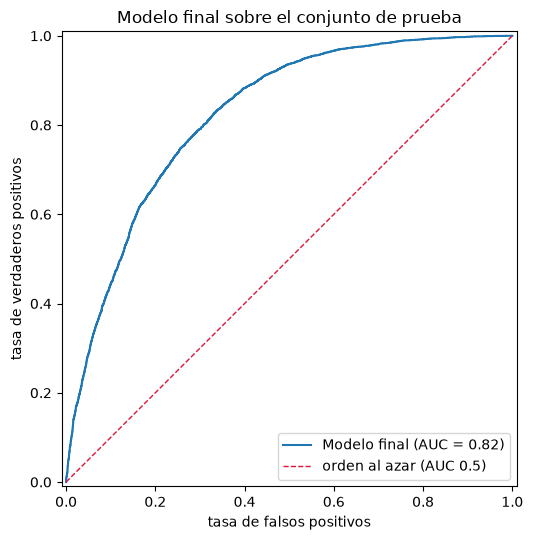

In [29]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
RocCurveDisplay.from_predictions(y_test, puntajes_prueba, name="Modelo final", ax=ax)
ax.plot([0, 1], [0, 1], color="crimson", linestyle="--", linewidth=1, label="orden al azar (AUC 0.5)")
ax.set_xlabel("tasa de falsos positivos")
ax.set_ylabel("tasa de verdaderos positivos")
ax.set_title("Modelo final sobre el conjunto de prueba")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

✍️ **Entregable 7 de 8 — La prueba final**

- **El modelo final**: gradient boosting con `learning_rate` 0.0228, 396 árboles de profundidad 5,
  `subsample` 0.6526 y al menos 53 filas por hoja, reajustado sobre las 56,553 filas de entrenamiento
  con el preprocesamiento de la Sección 4.
- **Su puntaje de prueba**: 0.8233 en el conjunto de prueba, frente a una estimación de validación
  cruzada de 0.8296 con una dispersión entre pliegues de 0.0023.
- **Qué significa la brecha**: el puntaje de prueba queda 0.0063 por debajo de la estimación de CV,
  algo más de una dispersión de pliegue (0.0023) pero una diferencia absoluta pequeña (0.83 frente a
  0.82). Esto es consistente con la variación normal de muestreo entre los pliegues de entrenamiento y
  las filas de prueba separadas, más que con una fuga de información (leakage) — nada en el pipeline
  permite que el modelo vea valores del conjunto de prueba — o con una prueba inusualmente fácil, ya
  que el puntaje bajó, no subió.
- **Uso del conjunto de prueba**: `X_test`/`y_test` aparecen solo en la Sección 3 (la partición) y
  aquí. Nada se cambió después de calcular este puntaje.

## 8. Conclusiones

✍️ **Entregable 8 de 8 — Conclusiones**

- **Recomendación**: usar el modelo de gradient boosting ajustado para ordenar a las personas
  encuestadas al estilo BRFSS según su riesgo estimado de diabetes/prediabetes, y que un programa de
  tamizaje trabaje ese ranking desde la persona de mayor riesgo hasta donde alcance su presupuesto de
  exámenes.
- **Qué esperar en datos nuevos**: en personas que el modelo no ha visto, ordena a alguien con
  diabetes/prediabetes por encima de alguien sin ella aproximadamente con la frecuencia que indica el
  AUC de prueba de la Sección 7 (0.8233) — bien por encima del azar (0.5), pero lejos de un
  ordenamiento perfecto (1.0).
- **Limitaciones**:
  1. El torneo comparó modelos en sus configuraciones iniciales, no ajustadas, y solo el ganador
     (gradient boosting) fue ajustado; la regresión logística y KNN quedaron cerca sin ajustar y nunca
     tuvieron la misma oportunidad de mejorar.
  2. Este dataset es una muestra balanceada 50/50 construida descartando a la mayoría de las personas
     negativas del archivo original de BRFSS 2015 (253,680 filas); un modelo entrenado aquí
     sobreestimará cuántas personas en la población general (~14% positiva) están realmente en riesgo,
     a menos que sus puntajes se recalibren antes de usarse en producción.
  3. El modelo ordena a las personas pero no dice a cuántas examinar; ese umbral necesita el costo de
     un examen de seguimiento y el daño de un caso no detectado, ninguno de los cuales tiene este
     notebook.
- **Siguiente paso**: pedir al programa de salud esos costos, elegir un umbral a partir de ellos, y
  recalibrar las probabilidades del modelo contra la prevalencia real del 14% antes de usarlo fuera de
  esta muestra balanceada de investigación.